In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('processed_titanic.csv')


In [18]:
X = df.drop(['Survived', 'PassengerId'], axis=1)
y = df['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Обучающая: {X_train.shape[0]}")
print(f"Тестовая: {X_test.shape[0]}")
print(f"Валидационная: {X_val.shape[0]}")

Обучающая: 534
Тестовая: 178
Валидационная: 179


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Признаки и целевая переменная для регрессии
reg_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']

X_train_reg = X_train[reg_features]
X_test_reg = X_test[reg_features]
y_train_reg = X_train['Fare'] if 'Fare' in X_train.columns else df.loc[X_train.index, 'Fare']
y_test_reg = X_test['Fare'] if 'Fare' in X_test.columns else df.loc[X_test.index, 'Fare']

# Но Fare есть в X, поэтому берём оттуда и убираем из признаков
y_train_reg = df.loc[X_train.index, 'Fare']
y_test_reg = df.loc[X_test.index, 'Fare']

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
y_pred_reg = linear_model.predict(X_test_reg)

print("Коэффициенты:", dict(zip(reg_features, linear_model.coef_.round(4))))
print(f"Intercept: {linear_model.intercept_:.4f}")

Коэффициенты: {'Pclass': np.float64(-0.1317), 'Age': np.float64(-0.0061), 'SibSp': np.float64(0.0888), 'Parch': np.float64(0.136), 'Sex_male': np.float64(-0.0054), 'Embarked_Q': np.float64(-0.025), 'Embarked_S': np.float64(-0.0379)}
Intercept: 0.1726


MSE  = 0.003039 средний квадрат ошибки
RMSE = 0.055124
MAE  = 0.037379 средняя абсолютная ошибка
R²   = 0.5134  доля дисперсии данных, которую объясняет модель


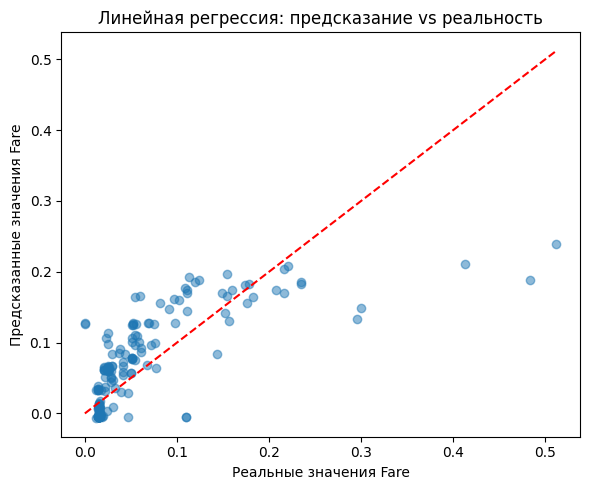

In [20]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MSE  = {mse:.6f} средний квадрат ошибки")  
print(f"RMSE = {rmse:.6f}")
print(f"MAE  = {mae:.6f} средняя абсолютная ошибка")
print(f"R²   = {r2:.4f}  доля дисперсии данных, которую объясняет модель")

# График: предсказание vs реальность
plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([0, y_test_reg.max()], [0, y_test_reg.max()], 'r--')
plt.xlabel('Реальные значения Fare')
plt.ylabel('Предсказанные значения Fare')
plt.title('Линейная регрессия: предсказание vs реальность')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import Ridge
# улучшенис ridge регуляризация L2
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_model.predict(X_test_reg)

print("Ridge (L2, alpha=1.0):")
print(f"  MSE  = {mean_squared_error(y_test_reg, y_pred_ridge):.6f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.6f}")
print(f"  MAE  = {mean_absolute_error(y_test_reg, y_pred_ridge):.6f}")
print(f"  R²   = {r2_score(y_test_reg, y_pred_ridge):.4f}")

Ridge (L2, alpha=1.0):
  MSE  = 0.003029
  RMSE = 0.055036
  MAE  = 0.036760
  R²   = 0.5150


In [22]:
from sklearn.linear_model import LogisticRegression

clf_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
# задача классификации - предсказание survived
X_train_clf = X_train[clf_features]
X_test_clf = X_test[clf_features]

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_clf, y_train)
y_pred_clf = logreg.predict(X_test_clf)

print("Коэффициенты:", dict(zip(clf_features, logreg.coef_[0].round(4))))
print(f"Intercept: {logreg.intercept_[0]:.4f}")

Коэффициенты: {'Pclass': np.float64(-1.6543), 'Age': np.float64(-1.3466), 'SibSp': np.float64(-1.1048), 'Parch': np.float64(-0.3792), 'Fare': np.float64(0.4843), 'Sex_male': np.float64(-2.5251), 'Embarked_Q': np.float64(-0.0972), 'Embarked_S': np.float64(-0.6156)}
Intercept: 3.0947


In [23]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report)
# оценка классификационной модели
print(f"Accuracy:  {accuracy_score(y_test, y_pred_clf):.4f} доля правильных ответов. ")
print(f"Precision: {precision_score(y_test, y_pred_clf):.4f} из всех, кого модель назвала «выжил», сколько реально выжило.")
print(f"Recall:    {recall_score(y_test, y_pred_clf):.4f} из всех реально выживших, сколько модель нашла")
print(f"F1-score:  {f1_score(y_test, y_pred_clf):.4f} гармоническое среднее")

print("\nПолный отчёт:")
print(classification_report(y_test, y_pred_clf, target_names=['Не выжил', 'Выжил']))

Accuracy:  0.7528 доля правильных ответов. 
Precision: 0.6721 из всех, кого модель назвала «выжил», сколько реально выжило.
Recall:    0.6308 из всех реально выживших, сколько модель нашла
F1-score:  0.6508 гармоническое среднее

Полный отчёт:
              precision    recall  f1-score   support

    Не выжил       0.79      0.82      0.81       113
       Выжил       0.67      0.63      0.65        65

    accuracy                           0.75       178
   macro avg       0.73      0.73      0.73       178
weighted avg       0.75      0.75      0.75       178



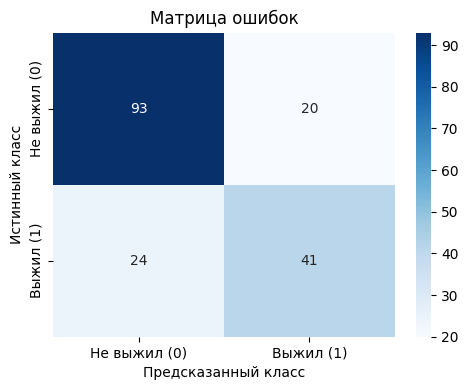

In [ ]:
# Матрица ошибок
#Верхняя левая (93) — TN: реально не выжил, модель сказала «не выжил» 
#Верхняя правая (20) — FP: реально не выжил, но модель сказала «выжил» 
#Нижняя левая (24) — FN: реально выжил, но модель сказала «не выжил» 
#Нижняя правая (41) — TP: реально выжил, модель сказала «выжил» 
#Проверка: 93+20+24+41 = 178 — это ровно размер тестовой выборки. Accuracy = (93+41)/178 = 134/178 = 0.7528 — совпадает с тем, что выдала модель. Precision = 41/(41+20) = 0.672, Recall = 41/(41+24) = 0.631 — тоже совпадает.
cm = confusion_matrix(y_test, y_pred_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не выжил (0)', 'Выжил (1)'],
            yticklabels=['Не выжил (0)', 'Выжил (1)'])
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## Выводы**Регрессия:** линейная модель предсказывает Fare с R² ≈ 0.51. Главный предиктор — класс каюты. Ridge регуляризация помогает стабилизировать веса.
**Классификация:** логистическая регрессия даёт Accuracy ≈ 0.75, F1 ≈ 0.65. Ключевые факторы выживания — пол, класс каюты и возраст.